In [17]:
import os
os.sys.path.append('/data/scratch/globc/bonassies/workspace/swot_for_flood')
import geopandas as gpd
import configparser
from pathlib import Path
from matplotlib import pyplot as plt
import seaborn as sns
from cmap import Colormap

from core.swot_project import SwotProject
from core.plot_raster import PlotRaster

main_path = "/data/scratch/globc/bonassies/workspace/swot_for_flood/examples/Mozambique"

# Plotting for Chinon

This notebook uses the rasters generated before to plot the results of the Chinon exercise. The rasters are stored in the `rasters` folder and the plots are stored in the `plots` folder.

First, we need to load the project:

In [18]:
config = configparser.ConfigParser()
config.read(main_path + '/config.cfg')

# print(type(config),dict(config['CONFIG']))

['/data/scratch/globc/bonassies/workspace/swot_for_flood/examples/Mozambique/config.cfg']

In [19]:
swot_project = SwotProject(config)
# print(swot_project)

Data path already exists in /data/scratch/globc/bonassies/data or download is set to False
SWOT data already exists in /data/scratch/globc/bonassies/data/SWOT or download is set to False
SWOT project already exists in /data/scratch/globc/bonassies/data/SWOT/Mozambique or download is set to False
Geopackage already exists in /data/scratch/globc/bonassies/workspace/swot_for_flood/examples/Mozambique/gpkg_combined or make_gpkg is set to False
TIFF path already exists in /data/scratch/globc/bonassies/workspace/swot_for_flood/examples/Mozambique/rasters or make_tiff is set to False
No automatic download, please use the Downloader object to download the data


In [20]:
swot_project.find_raster()
print(swot_project.rasters_list)


[PosixPath('/data/scratch/globc/bonassies/workspace/swot_for_flood/examples/Mozambique/rasters/SWOT_epsg32736_20250906T021728_combined.tif'), PosixPath('/data/scratch/globc/bonassies/workspace/swot_for_flood/examples/Mozambique/rasters/SWOT_epsg32736_20250926T230231_combined.tif'), PosixPath('/data/scratch/globc/bonassies/workspace/swot_for_flood/examples/Mozambique/rasters/SWOT_epsg32736_20251107T163241_combined.tif'), PosixPath('/data/scratch/globc/bonassies/workspace/swot_for_flood/examples/Mozambique/rasters/SWOT_epsg32736_20251017T194737_combined.tif'), PosixPath('/data/scratch/globc/bonassies/workspace/swot_for_flood/examples/Mozambique/rasters/SWOT_epsg32736_20250726T084719_combined.tif'), PosixPath('/data/scratch/globc/bonassies/workspace/swot_for_flood/examples/Mozambique/rasters/SWOT_epsg32736_20250614T151707_combined.tif'), PosixPath('/data/scratch/globc/bonassies/workspace/swot_for_flood/examples/Mozambique/rasters/SWOT_epsg32736_20250705T120214_combined.tif'), PosixPath('/

Then, once loaded, we need to create, load and pre-treat the SWOT data used for plotting.
Here we use the collection object within the project to create a new collection with the dry and flooded times selected.

In [21]:
# takes around 2 minutes for 5 raster files of 1.65Go
swot_project.create_collection()

Opening SWOT raster at time: 2026-01-09 06:47:54
Opening SWOT raster at time: 2025-06-14 15:17:07
Opening SWOT raster at time: 2025-07-05 12:02:14
Opening SWOT raster at time: 2025-09-26 23:02:31
Opening SWOT raster at time: 2025-11-07 16:32:41
Opening SWOT raster at time: 2025-12-19 10:02:49
Opening SWOT raster at time: 2025-05-24 18:32:03
Opening SWOT raster at time: 2025-08-16 05:32:23
Opening SWOT raster at time: 2025-10-17 19:47:37
Opening SWOT raster at time: 2025-09-06 02:17:28
Opening SWOT raster at time: 2025-11-28 13:17:45
Opening SWOT raster at time: 2025-07-26 08:47:19
Opening SWOT raster at time: 2025-05-24 18:32:03


We can then create the plot object that we will use to plot the data.

In [22]:
plot_obj = PlotRaster(
    swot_project,
    save_fig=False,
    show_fig=True
    )

In [ ]:
# plot_obj.plot_all_rasters("sig0", vmin=0, vmax=1)

# Gamma_tot

Finally, we can plot the data using the plot object.

Below, a function to plot the control area and histograms associated with the control area.

In [9]:
# plot_obj.plot_control_maps_and_histograms(
#     'gamma_tot', 
#     time_selection="2024-03-31",
#     cmap=Colormap("seaborn:mako").to_matplotlib(),
#     y_label="Chinon, France",
#     vmin=0,
#     vmax=1,
#     )


Plot mean histograms with the dates that compose the mean.

In [ ]:
# fig,ax = plot_obj.plot_mean_hist_computation(
#     'gamma_tot',
#     hist_range=(0,1),
#     add_legend=False
# )

Below, the function to plot a map.

In [25]:
import numpy as np
from scipy.ndimage import uniform_filter

def compute_coherence(slc1, slc2, win_size=5):
      mask_slc1 = np.isnan(slc1)
      mask_slc2 = np.isnan(slc2)
      slc1 = np.nan_to_num(slc1, nan=0.0)
      slc2 = np.nan_to_num(slc2, nan=0.0)  
      
      # Interferogram
      interferogram = slc1 * np.conj(slc2)
      
      # Local averaging
      num = uniform_filter(interferogram.real, win_size) + \
            1j * uniform_filter(interferogram.imag, win_size)
      
      denom1 = uniform_filter(np.abs(slc1)**2, win_size)
      denom2 = uniform_filter(np.abs(slc2)**2, win_size)
      
      coherence = np.abs(num) / np.sqrt(denom1 * denom2)
      
      coherence[mask_slc1 | mask_slc2] = np.nan  # Set coherence to NaN where either SLC is NaN
      
      return coherence

In [24]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

data = plot_obj.swot_collection.swot_flood_rasters
print(data)
data = data.sortby("time")

variables = ["gamma_tot", "sig0", "coherent_power"]
# variables = ["coherent_power"]
for variable in variables:
    if variable == "coherent_power":
        da = np.log10(data.coherent_power) * 10
    elif variable == "sig0":
        da = np.log10(data.sig0) * 10
    else: 
        da = data[variable]

    # remove empty dates
    mask_time = np.full_like(da.time.values, False, dtype=bool)
    for t in da.time.values:
        if np.isnan(da.sel(time=t)).all():
            mask_time[da.time.values == t] = True
    da = da.sel(time=~mask_time)


    fig, ax = plt.subplots()

    ax.spines.right.set_visible(False)
    ax.spines.top.set_visible(False)
    ax.xaxis.set_visible(False)
    ax.yaxis.set_visible(False)

    ax.set_facecolor('black')
    def update(frame):
        tmp = da.isel(time=frame)
        ax.clear()
        if variable == "gamma_tot":
            vmin, vmax = 0.4, 1
        elif variable == "sig0":
            vmin, vmax = -15, 15
        elif variable == "coherent_power":
            vmin, vmax = 60, 80
        da.isel(time=frame).plot(ax=ax, cmap=Colormap("seaborn:mako").to_matplotlib(), vmin=vmin, vmax=vmax, add_colorbar=False) # coherent_power
        ax.set_title(str(da.time.values[frame].astype('datetime64[D]')))
        
        ax.spines.right.set_visible(False)
        ax.spines.top.set_visible(False)
        ax.xaxis.set_visible(False)
        ax.yaxis.set_visible(False)
        ax.set_facecolor('black')

    ani = FuncAnimation(fig, update, frames=len(da.time))

    ani.save(f"/data/scratch/globc/bonassies/workspace/swot_for_flood/examples/Mozambique/plots/animation_{variable}.gif", writer=PillowWriter(fps=1))
    # ani.save(f"/data/scratch/globc/bonassies/workspace/swot_for_flood/examples/Mozambique/plots/animation_{variable}.webp", writer=PillowWriter(fps=5))
    
    plt.close(fig)
    del ani

<xarray.Dataset> Size: 323MB
Dimensions:         (time: 12, y: 951, x: 1416)
Coordinates:
  * time            (time) datetime64[ns] 96B 2026-01-09T06:47:54 ... 2025-07...
  * x               (x) float64 11kB 5.548e+05 5.549e+05 ... 5.69e+05 5.69e+05
  * y               (y) float64 8kB 7.245e+06 7.245e+06 ... 7.236e+06 7.236e+06
    spatial_ref     int64 8B 0
Data variables:
    sig0            (time, y, x) float32 65MB dask.array<chunksize=(1, 500, 500), meta=np.ndarray>
    coherent_power  (time, y, x) float32 65MB dask.array<chunksize=(1, 500, 500), meta=np.ndarray>
    gamma_tot       (time, y, x) float32 65MB dask.array<chunksize=(1, 500, 500), meta=np.ndarray>
    gamma_SNR       (time, y, x) float32 65MB dask.array<chunksize=(1, 500, 500), meta=np.ndarray>
    classification  (time, y, x) float32 65MB dask.array<chunksize=(1, 500, 500), meta=np.ndarray>
Attributes:
    AREA_OR_POINT:  Area


Below a function to plot an histogram.

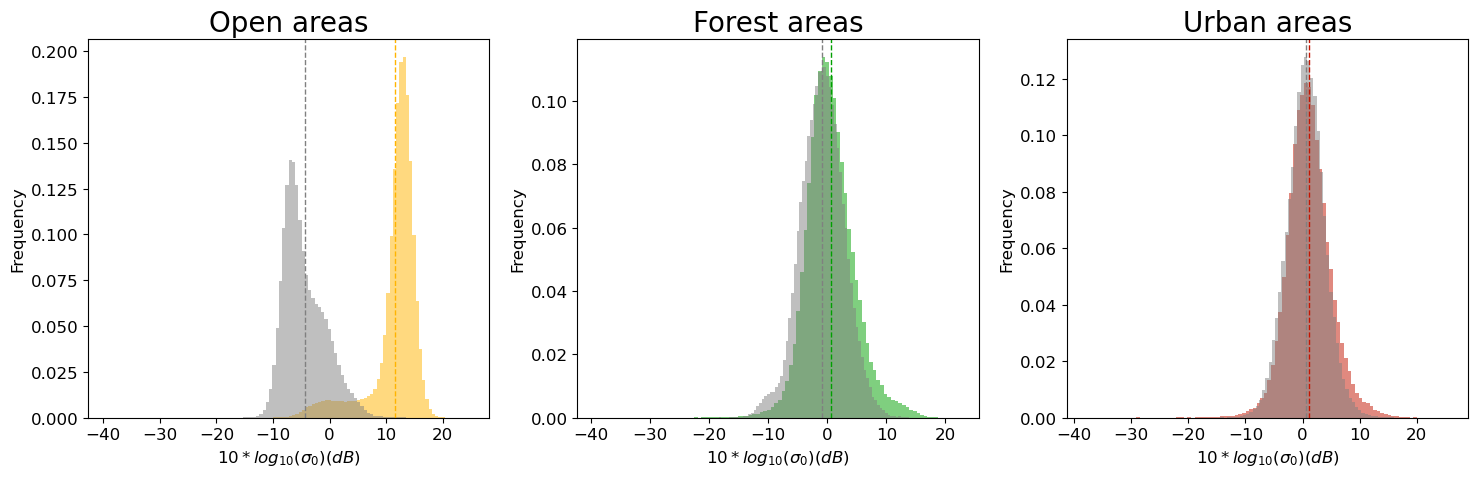

In [96]:
# takes around 1 minute for seaborn method, 15s for matplotlib method
fig, ax = plot_obj.plot_all_histograms(
    variable="sig0",
    data_type="swot",
    # range_hist=(-20, 20),
    time_selection="2026-01-30",
    use_seaborn=False
    )

In [75]:

plot_obj.plot_classification(time_selection="2026-01-30", show_fig=True)


(<Figure size 1000x1000 with 1 Axes>, <GeoAxes: label='map'>)

And then, the function to combine maps and histograms.

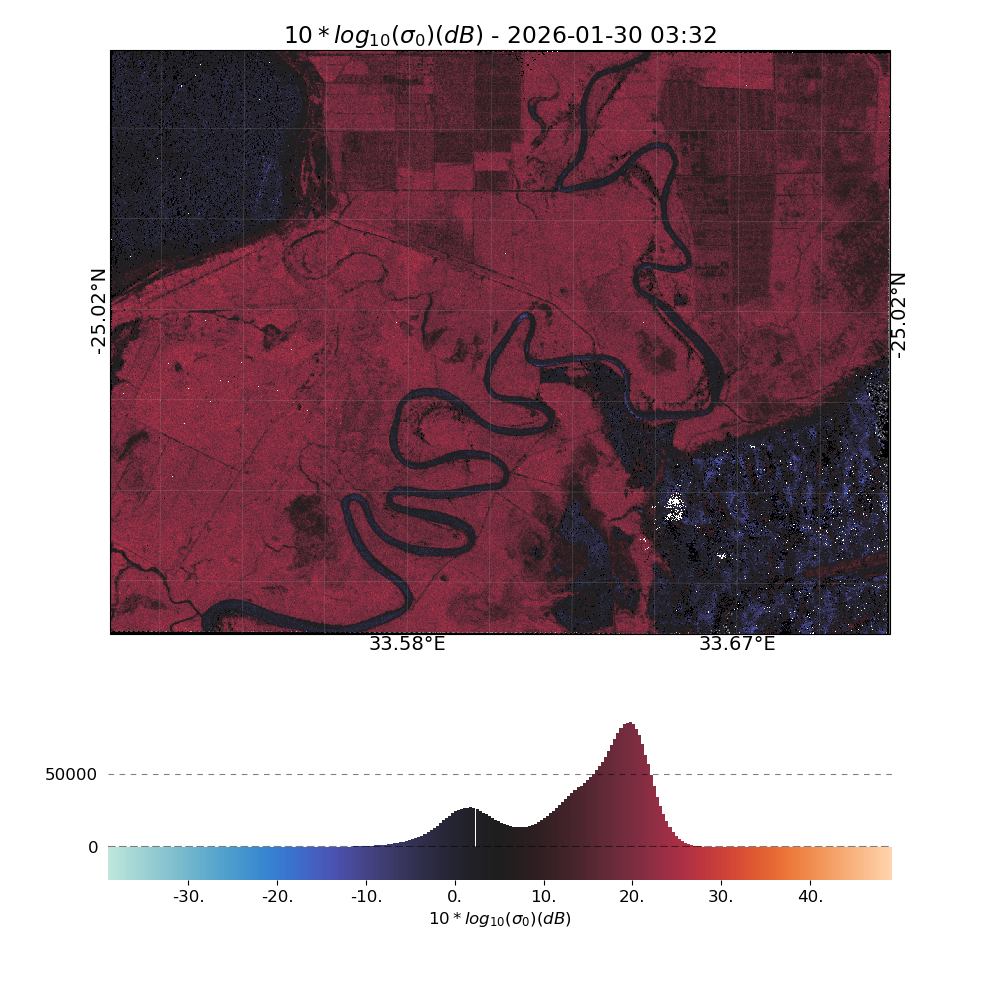

In [104]:
# takes around 1 minute 15s for matplotlib method, 4 minutes for seaborn method
fig, ax = plot_obj.plot_map(
    variable="sig0",
    data_area="global",
    data_type="diff",
    # world_cover_mask=['urban'],
    time_selection="2026-01-30",
    add_bkg=False,
    # vmin=-1, vmax=1,
    cmap=Colormap("seaborn:icefire").to_matplotlib(),
    # cmap=Colormap("seaborn:mako").to_matplotlib(),
    # use_seaborn=False
    )
plt.show(fig)

In [ ]:
# import cartopy
# import matplotlib.patches as mpatches
# print("Creating flood mask...")
# plot_obj.swot_collection.create_flood_mask(
#     variable="coherent_power",
#     data_area="global",
#     data_type="diff",
#     thresholds={"urban":4, "forest":4, "open":4},
#     time_selection="2026-01-30",
#     add_uncertainty=False,
#     threshold_gamma=0.5,
#     threshold_SNR=0.5,
#     )

# print("Plotting flood mask...")
# fig, ax = plot_obj.plot_map_mask(
#     variable="coherent_power",
#     data_area="global",
#     data_type="diff",
#     time_selection="2026-01-30",
#     comparing_raster_Path=None,
#     add_scores=False,
#     add_bkg=False,
#     add_legend=False,
#     figsize=(10,7)
#     )

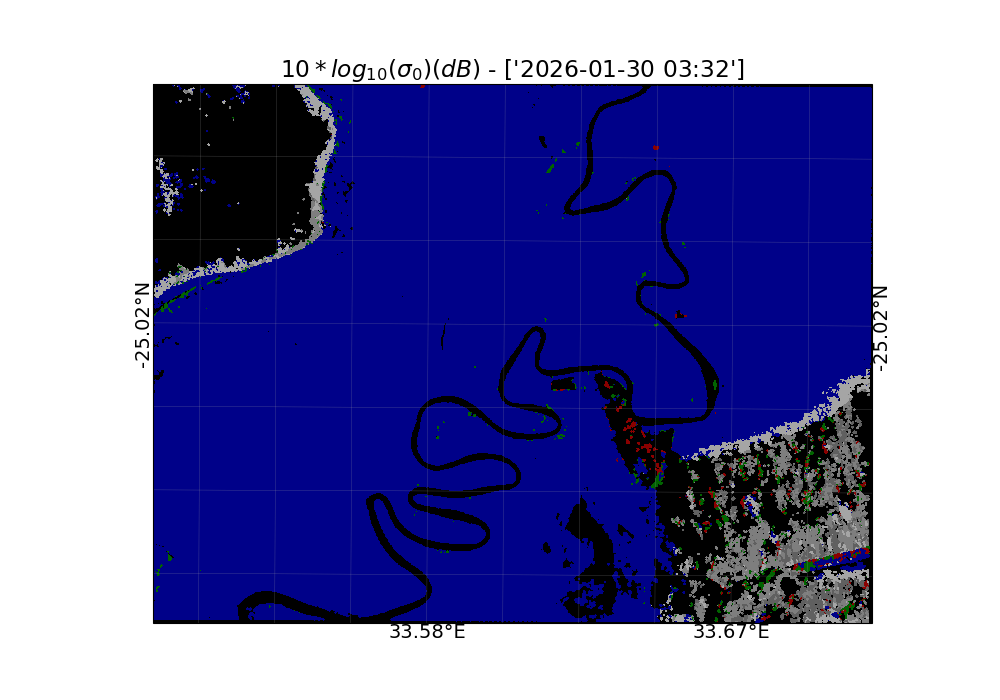

In [111]:
import cartopy
import matplotlib.patches as mpatches
print("Creating flood mask...")
plot_obj.swot_collection.create_flood_mask(
    variable="sig0",
    data_area="global",
    data_type="diff",
    # thresholds={"urban":3, "forest":3, "open":3}, # coherent_power
    thresholds={"urban":4, "forest":4, "open":4}, # sig0
    # thresholds={"urban":0.02, "forest":0.1, "open":0.1}, # gamma_tot
    # urban_diff=True,
    # forest_diff=True,
    # open_diff=True,
    time_selection="2026-01-30",
    add_uncertainty=True,
    threshold_gamma=0.5,
    threshold_SNR=0.6,
    )

print("Plotting flood mask...")
fig, ax = plot_obj.plot_map_mask(
    variable="sig0",
    data_area="global",
    data_type="diff",
    time_selection="2026-01-30",
    comparing_raster_Path=None,
    add_scores=False,
    add_bkg=False,
    add_legend=False,
    figsize=(10,7)
    )

In [ ]:

plot_obj.swot_collection.save_tiff(
    variable='gamma_tot',
    data_type="mean",
    is_mask=False,
    path=Path("/data/scratch/globc/bonassies/workspace/swot_for_flood/examples/Mozambique/plots/mean_gamma_tot.tif")
    )
plot_obj.swot_collection.save_tiff(
    variable='coherent_power',
    data_type="mean",
    is_mask=False,
    path=Path("/data/scratch/globc/bonassies/workspace/swot_for_flood/examples/Mozambique/plots/mean_coherent_power.tif")
    )
plot_obj.swot_collection.save_tiff(
    variable='sig0',
    data_type="mean",
    is_mask=False,
    path=Path("/data/scratch/globc/bonassies/workspace/swot_for_flood/examples/Mozambique/plots/mean_sig0.tif")
    )

plot_obj.swot_collection.save_tiff(
    variable='gamma_tot',
    data_type="swot",
    time_selection="2026-01-30",
    is_mask=True,
    path=Path("/data/scratch/globc/bonassies/workspace/swot_for_flood/examples/Mozambique/plots/mask_gamma_tot.tif")
    )
plot_obj.swot_collection.save_tiff(
    variable='sig0',
    data_type="swot",
    time_selection="2026-01-30",
    is_mask=True,
    path=Path("/data/scratch/globc/bonassies/workspace/swot_for_flood/examples/Mozambique/plots/mask_sig0.tif")
    )
plot_obj.swot_collection.save_tiff(
    variable='sig0',
    data_type="diff",
    time_selection="2026-01-30",
    is_mask=True,
    path=Path("/data/scratch/globc/bonassies/workspace/swot_for_flood/examples/Mozambique/plots/mask_sig0_diff.tif")
    )
plot_obj.swot_collection.save_tiff(
    variable='coherent_power',
    data_type="diff",
    time_selection="2026-01-30",
    is_mask=True,
    path=Path("/data/scratch/globc/bonassies/workspace/swot_for_flood/examples/Mozambique/plots/mask_coherent_power_diff.tif")
    )

plot_obj.swot_collection.save_tiff(
    variable='coherent_power',
    data_type="diff",
    time_selection="2026-01-30",
    is_mask=False,
    path=Path("/data/scratch/globc/bonassies/workspace/swot_for_flood/examples/Mozambique/plots/diff_coherent_power.tif")
    )
plot_obj.swot_collection.save_tiff(
    variable='gamma_tot',
    data_type="diff",
    time_selection="2026-01-30",
    is_mask=False,
    path=Path("/data/scratch/globc/bonassies/workspace/swot_for_flood/examples/Mozambique/plots/diff_gamma_tot.tif")
    )
plot_obj.swot_collection.save_tiff(
    variable='sig0',
    data_type="diff",
    time_selection="2026-01-30",
    is_mask=False,
    path=Path("/data/scratch/globc/bonassies/workspace/swot_for_flood/examples/Mozambique/plots/diff_sig0.tif")
    )

<xarray.DataArray 'coherent_power' (time: 1, y: 1502, x: 2002)> Size: 12MB
dask.array<sub, shape=(1, 1502, 2002), dtype=float32, chunksize=(1, 500, 500), chunktype=numpy.ndarray>
Coordinates:
  * time         (time) datetime64[ns] 8B 2026-01-30T03:32:59
  * x            (x) float64 16kB 5.513e+05 5.513e+05 ... 5.713e+05 5.713e+05
  * y            (y) float64 12kB 7.24e+06 7.24e+06 ... 7.225e+06 7.225e+06
    spatial_ref  int64 8B 0
<xarray.DataArray 'gamma_tot' (time: 1, y: 1502, x: 2002)> Size: 12MB
dask.array<sub, shape=(1, 1502, 2002), dtype=float32, chunksize=(1, 500, 500), chunktype=numpy.ndarray>
Coordinates:
  * time         (time) datetime64[ns] 8B 2026-01-30T03:32:59
  * x            (x) float64 16kB 5.513e+05 5.513e+05 ... 5.713e+05 5.713e+05
  * y            (y) float64 12kB 7.24e+06 7.24e+06 ... 7.225e+06 7.225e+06
    spatial_ref  int64 8B 0
<xarray.DataArray 'sig0' (time: 1, y: 1502, x: 2002)> Size: 12MB
dask.array<sub, shape=(1, 1502, 2002), dtype=float32, chunksize=(1, 

# coherent power

In [ ]:
fig, ax = plot_obj.plot_all_histograms(
    variable="coherent_power",
    data_area="flood",
    data_type="swot",
    time_selection="2024-03-31",
    use_seaborn=False
    )

In [ ]:
print("Creating flood mask...")
plot_obj.swot_collection.create_flood_mask(
    variable="coherent_power",
    data_area="global",
    data_type="swot",
    thresholds={"urban":-0, "forest":64, "open":64},
    time_selection="2024-03-31",
    add_uncertainty=True,
    )

print("Plotting flood mask...")
fig, ax = plot_obj.plot_map_mask(
    variable="coherent_power",
    data_area="global",
    data_type="swot",
    time_selection="2024-03-31",
    comparing_raster_Path=swot_project.AUX_PATH.joinpath("FM_30TYT_20240331T174856_S1_132_POST_nrow1496_ncol2635.tif"),
    add_classif_score=True,
    add_uncertainty=True,
    add_bkg=False,
    add_legend=True,
    figsize=(10,7)
    )

# Sigma 0

In [ ]:
fig,ax = plot_obj.plot_map(
    variable="sig0",
    data_area="global",
    data_type="diff",
    time_selection="2024-03-31",
    cmap= 'coolwarm',
    vmin=-35,
    vmax=35,
    add_bkg=False,
    )

In [ ]:
fig, ax = plot_obj.plot_all_histograms(
    variable="sig0",
    data_area="global",
    data_type="diff",
    time_selection="2024-03-31",
    use_seaborn=False
    )

In [ ]:
fig, ax = plot_obj.plot_all_histograms(
    variable="sig0",
    data_area="global",
    data_type="swot",
    time_selection="2024-03-31",
    use_seaborn=False
    )

In [ ]:
print("Creating flood mask...")
plot_obj.swot_collection.create_flood_mask(
    variable="sig0",
    data_area="global",
    data_type="swot",
    thresholds={"urban":-0, "forest":10, "open":10},
    time_selection="2024-03-31",
    add_uncertainty=True,
    )

print("Plotting flood mask...")
fig, ax, m_data = plot_obj.plot_map_mask(
    variable="sig0",
    data_area="global",
    data_type="swot",
    time_selection="2024-03-31",
    comparing_raster_Path=swot_project.AUX_PATH.joinpath("FM_30TYT_20240331T174856_S1_132_POST_nrow1496_ncol2635.tif"),
    add_classif_score=True,
    add_uncertainty=True,
    add_bkg=False,
    add_legend=True,
    figsize=(10,7)
    )

ax[0].add_patch(
    mpatches.Rectangle(
        xy=(0.28, 47.1),  # lower left corner
        width=0.03,  # width of rectangle
        height=0.05,  # height of rectangle
        linewidth=2,
        linestyle='--',
        edgecolor="red",
        fill=False,
        transform=cartopy.crs.PlateCarree()._as_mpl_transform(ax[-1]),
    )
)
ax[0].annotate(
    "A",
    xy=(0.28, 47.11),
    fontsize=20,
    color="red",
    ha='center',
    va='center',
    bbox = dict(boxstyle="round", fc="w", ec="w", lw=0, alpha=0.5),
)
m_data.show()

# Merged

In [ ]:
print("Creating flood mask...")
plot_obj.swot_collection.create_flood_mask(
    variable="sig0",
    data_area="global",
    data_type="swot",
    thresholds={"urban":-0, "forest":10, "open":10},
    time_selection="2024-03-31",
    add_uncertainty=True,
    )
plot_obj.swot_collection.create_flood_mask(
    variable="coherent_power",
    data_area="global",
    data_type="swot",
    thresholds={"urban":-0, "forest":64, "open":64},
    time_selection="2024-03-31",
    add_uncertainty=True,
    )
plot_obj.swot_collection.create_flood_mask(
    variable="gamma_tot",
    data_area="global",
    data_type="swot",
    thresholds={"urban":-0, "forest":0.75, "open":0.75},
    time_selection="2024-03-31",
    add_uncertainty=True,
    )

# merging flood masks
print("Merging flood masks...")
plot_obj.swot_collection.merge_flood_masks(data_area="global", data_type="swot", filter_variable="sig0")

print("Plotting flood mask...")
fig, ax = plot_obj.plot_map_mask(
    variable="merged",
    data_area="global",
    data_type="swot",
    time_selection="2024-03-31",
    comparing_raster_Path=swot_project.AUX_PATH.joinpath("FM_30TYT_20240331T174856_S1_132_POST_nrow1496_ncol2635.tif"),
    add_classif_score=True,
    add_uncertainty=True,
    add_bkg=False,
    add_legend=True,
    figsize=(10,7)
    )

# Scores

In [9]:
for variable in ["sig0", "coherent_power", "gamma_tot"]:
    print("-"*69)
    print("variable: ", variable)
    if variable == "sig0":
        Ohio_thresholds={"urban":-0, "forest":5.5, "open":9.5}
        PA_thresholds={"urban":-0, "forest":5, "open":10}
        PA_urban_diff=False
        Greece_thresholds={"urban":8, "forest":7, "open":9}
        Greece_urban_diff=True
        Chinon_thresholds={"urban":-0, "forest":10, "open":10}
        
    elif variable == "coherent_power":
        Ohio_thresholds={"urban":-0, "forest":62.5, "open":65}
        PA_thresholds={"urban":-0, "forest":62, "open":70}
        PA_urban_diff=False
        Greece_thresholds={"urban":70, "forest":65, "open":65}
        Greece_urban_diff=False
        Chinon_thresholds={"urban":-0, "forest":64, "open":64}
        
    elif variable == "gamma_tot":
        Ohio_thresholds={"urban":-0, "forest":0.7, "open":0.85}
        PA_thresholds={"urban":-0.1, "forest":0.65, "open":0.8} # swot with urban diff
        PA_urban_diff=True
        Greece_thresholds={"urban":0.9, "forest":0.85, "open":0.9}
        Greece_urban_diff=False
        Chinon_thresholds={"urban":-0, "forest":0.725, "open":0.725}
        
    # print("Flooded Area")
    # plot_obj.swot_collection.create_flood_mask(
    #     variable=variable,
    #     data_area="flood",
    #     data_type="swot",
    #     thresholds=Chinon_thresholds,
    #     threshold_SNR=0.5,
    #     threshold_gamma=0.5, #swot
    #     time_selection="2024-03-31",
    #     add_uncertainty=True,
    #     )

    # csi, _, _ = plot_obj.swot_collection.compute_scores(
    #     variable=variable,
    #     compared_raster_path=swot_project.AUX_PATH.joinpath("FloodMask_nrow1496_ncol2635.tif"),
    #     data_area="flood",
    #     data_type="swot",
    #     time_selection="2024-03-31",
    #     water_value=1,
    #     nan_value=-9999
    #     )
    # print("SWOT x HM       ", round(csi * 100, 2))
    
    # csi, _, _ = plot_obj.swot_collection.compute_scores(
    #     variable="classification",
    #     compared_raster_path=swot_project.AUX_PATH.joinpath("FloodMask_nrow1496_ncol2635.tif"),
    #     data_area="flood",
    #     data_type="swot",
    #     time_selection="2024-03-31",
    #     water_value=1,
    #     nan_value=-9999
    #     )
    # print("classif x HM    ", round(csi * 100, 2))
    
    # csi, _, _ = plot_obj.swot_collection.compute_scores(
    #     variable=variable,
    #     compared_raster_path=swot_project.AUX_PATH.joinpath("FM_30TYT_20240331T174856_S1_132_POST_nrow1496_ncol2635.tif"),
    #     data_area="flood",
    #     data_type="swot",
    #     time_selection="2024-03-31",
    #     water_value=1,
    #     nan_value=-9999
    #     )
    # print("SWOT x FM       ", round(csi * 100, 2))

    # csi, _, _ = plot_obj.swot_collection.compute_scores(
    #     variable="classification",
    #     compared_raster_path=swot_project.AUX_PATH.joinpath("FM_30TYT_20240331T174856_S1_132_POST_nrow1496_ncol2635.tif"),
    #     data_area="flood",
    #     data_type="swot",
    #     time_selection="2024-03-31",
    #     water_value=1,
    #     nan_value=-9999
    #     )
    # print("classif x FM    ", round(csi * 100, 2))

    # csi, _, _ = plot_obj.swot_collection.compute_scores(
    #     variable=variable,
    #     compared_raster_path="classification",
    #     data_area="flood",
    #     data_type="swot",
    #     time_selection="2024-03-31",
    #     water_value=1,
    #     nan_value=-9999
    #     )
    # print("SWOT x classif  ", round(csi * 100, 2))

    #############
    print("Global Area")
    plot_obj.swot_collection.create_flood_mask(
        variable=variable,
        data_area="global",
        data_type="swot",
        thresholds=Chinon_thresholds,
        threshold_SNR=0.5,
        threshold_gamma=0.5, #swot
        time_selection="2024-03-31",
        add_uncertainty=True,
        )

    csi, _, _ = plot_obj.swot_collection.compute_scores(
        variable=variable,
        compared_raster_path=swot_project.AUX_PATH.joinpath("FloodMask_nrow1496_ncol2635.tif"),
        data_area="global",
        data_type="swot",
        time_selection="2024-03-31",
        water_value=1,
        nan_value=-9999
        )
    print("SWOT x HM       ", round(csi * 100, 2))
    
    csi, _, _ = plot_obj.swot_collection.compute_scores(
        variable="classification",
        compared_raster_path=swot_project.AUX_PATH.joinpath("FloodMask_nrow1496_ncol2635.tif"),
        data_area="global",
        data_type="swot",
        time_selection="2024-03-31",
        water_value=1,
        nan_value=-9999
        )
    print("classif x HM    ", round(csi * 100, 2))
    
    csi, _, _ = plot_obj.swot_collection.compute_scores(
        variable=variable,
        compared_raster_path=swot_project.AUX_PATH.joinpath("FM_30TYT_20240331T174856_S1_132_POST_nrow1496_ncol2635.tif"),
        data_area="global",
        data_type="swot",
        time_selection="2024-03-31",
        water_value=1,
        nan_value=-9999
        )
    print("SWOT x FM       ", round(csi * 100, 2))

    csi, _, _ = plot_obj.swot_collection.compute_scores(
        variable="classification",
        compared_raster_path=swot_project.AUX_PATH.joinpath("FM_30TYT_20240331T174856_S1_132_POST_nrow1496_ncol2635.tif"),
        data_area="global",
        data_type="swot",
        time_selection="2024-03-31",
        water_value=1,
        nan_value=-9999
        )
    print("classif x FM    ", round(csi * 100, 2))

    csi, _, _ = plot_obj.swot_collection.compute_scores(
        variable=variable,
        compared_raster_path="classification",
        data_area="global",
        data_type="swot",
        time_selection="2024-03-31",
        water_value=1,
        nan_value=-9999
        )
    print("SWOT x classif  ", round(csi * 100, 2))



---------------------------------------------------------------------
variable:  sig0
Global Area
SWOT x HM        62.64
classif x HM     59.55
SWOT x FM        24.8
classif x FM     24.44
SWOT x classif   66.32
---------------------------------------------------------------------
variable:  coherent_power
Global Area
SWOT x HM        69.98
classif x HM     59.55
SWOT x FM        27.24
classif x FM     24.44
SWOT x classif   65.06
---------------------------------------------------------------------
variable:  gamma_tot
Global Area
SWOT x HM        64.92
classif x HM     59.55
SWOT x FM        25.76
classif x FM     24.44
SWOT x classif   58.46


In [10]:
import numpy as np

time_selection = "2024-03-31"
compared_raster_path = swot_project.AUX_PATH.joinpath("FM_30TYT_20240331T174856_S1_132_POST_nrow1496_ncol2635.tif")
_, mask_FloodML = plot_obj.swot_collection.pretreat_data_for_score(
    "classification", 
    compared_raster_path, 
    'global', 
    'swot', 
    time_selection, 
    1, 
    -9999
    )

compared_raster_path = swot_project.AUX_PATH.joinpath("FloodMask_nrow1496_ncol2635.tif")
_, mask_homemade = plot_obj.swot_collection.pretreat_data_for_score(
    "classification", 
    compared_raster_path, 
    'global', 
    'swot', 
    time_selection, 
    1, 
    -9999
    )

if np.count_nonzero(~np.isnan(mask_FloodML)) != np.count_nonzero(~np.isnan(mask_homemade)):
    print("WARNING: The compared raster and the SWOT Raster data have not the same non-nan number of pixels")

# compute TP, FP, TN, FN
true = mask_homemade
pred = mask_FloodML

contingency_map = np.ones(true.shape) * np.nan
contingency_map[np.logical_and(true == 1, pred == 1)] = 1 #'TP'
contingency_map[np.logical_and(true == 0, pred == 0)] = 0 #'TN'
contingency_map[np.logical_and(true == 0, pred == 1)] = 2 #'FP'
contingency_map[np.logical_and(true == 1, pred == 0)] = 3 #'FN'

TP_scale = np.nansum(contingency_map == 1)
TN_scale = np.nansum(contingency_map == 0)
FP_scale = np.nansum(contingency_map == 2)
FN_scale = np.nansum(contingency_map == 3)
total = TP_scale + FP_scale + TN_scale + FN_scale
if total != (~np.isnan(true)).flatten().sum():
    print("WARNING: The sum of TP, FP, TN and FN is not equal to the number of non-nan pixels in the compared raster data")
    
# compute critical success index (CSI)
if TP_scale + FP_scale + FN_scale == 0:
    CSI = 0
else:
    CSI = TP_scale / (TP_scale + FP_scale + FN_scale)

print("CSI: ", round(CSI * 100, 2))

CSI:  30.91
